# ColabFold

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.variant_attribution as vb
import src.proteingym as pg 
import src.onekg as og

import matplotlib.pyplot as plt
import seaborn as sns
import pooch
from tqdm import tqdm
import polars as pl
import glob

import src.colabfold as cf

pd.set_option('display.max_columns', None)

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [2]:
vep_files = va.list_vep_files(as_df=True)
vep_files.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

Found 859561 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 7
scoring_strategy: 3
variant_set: 1
haplotype: 111422
protein: 2251


,file,protein,haplotype,variant_set,model_location,scoring_strategy
0,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
1,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,masked-marginals
2,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
3,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,masked-marginals
4,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:914L>V,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals


## Get mean pLDDT for all ProteinGym proteins 

Get all the UniProt IDs from the ProteinGym mapping file.

In [3]:
pg_map = pg.get_mapping_file()

In [4]:
plddt_df = cf.get_plddt_all(protein_ids=pg_map["Uniprot_acc(HGNC/Uniprot)"].unique(), 
                            cache_only=True) 

  0%|          | 0/531 [00:00<?, ?it/s]

100%|██████████| 531/531 [00:00<00:00, 836.95it/s]


,pLDDT_mean
count,531.000000
mean,78.018632
std,12.631373
min,38.655870
25%,69.484855
50%,80.335210
75%,88.264264
max,98.415979


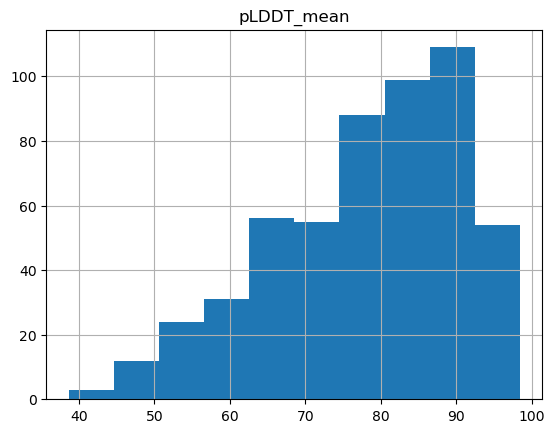

In [5]:
plddt_mean = plddt_df.groupby("uniprot_id")["pLDDT"].mean().sort_values(ascending=False).reset_index(name="pLDDT_mean")
plddt_mean.hist()

plddt_mean.describe()

In [7]:
top_plddt_proteins = pg_map.merge(
    plddt_mean.loc[plddt_mean["pLDDT_mean"] > 90][["uniprot_id", "pLDDT_mean"]],
    left_on="Uniprot_acc(HGNC/Uniprot)",
    right_on="uniprot_id",
    how="inner"
)
# Add the number of haplotypes for each protein
n_haplotypes = vep_files.groupby("protein")["haplotype"].nunique().reset_index(name="n_haplotypes")
top_plddt_proteins = top_plddt_proteins.merge(n_haplotypes, left_on="protein", right_on="protein", how="inner")
top_plddt_proteins["HGNC"] = top_plddt_proteins["GENEINFO"].str.split(":").str[0]

print(top_plddt_proteins.shape)
print("proteins with pLDDT>90: ", top_plddt_proteins["protein"].nunique())
top_plddt_proteins.head()

(1662, 854)
proteins with pLDDT>90:  88


,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,protein,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,mutant,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,protein_sequence,mutated_sequence,ClinSigSimple,aaref,aaalt,rs_dbSNP,hg19_chr,hg19_pos(1-based),hg18_chr,hg18_pos(1-based),aapos,genename,Ensembl_geneid,Ensembl_transcriptid,Ensembl_proteinid,Uniprot_acc,Uniprot_entry,HGVSc_ANNOVAR,HGVSp_ANNOVAR,HGVSc_snpEff,HGVSp_snpEff,HGVSc_VEP,HGVSp_VEP,APPRIS,GENCODE_basic,TSL,VEP_canonical,cds_strand,refcodon,codonpos,codon_degeneracy,Ancestral_allele,AltaiNeandertal,Denisova,VindijiaNeandertal,ChagyrskayaNeandertal,SIFT_score,SIFT_converted_rankscore,SIFT_pred,SIFT4G_score,SIFT4G_converted_rankscore,SIFT4G_pred,Polyphen2_HDIV_score,Polyphen2_HDIV_rankscore,Polyphen2_HDIV_pred,Polyphen2_HVAR_score,Polyphen2_HVAR_rankscore,Polyphen2_HVAR_pred,LRT_score,LRT_converted_rankscore,LRT_pred,LRT_Omega,MutationTaster_score,MutationTaster_converted_rankscore,MutationTaster_pred,MutationTaster_model,MutationTaster_AAE,MutationAssessor_score,MutationAssessor_rankscore,MutationAssessor_pred,FATHMM_score,FATHMM_converted_rankscore,FATHMM_pred,PROVEAN_score,PROVEAN_converted_rankscore,PROVEAN_pred,VEST4_score,VEST4_rankscore,MetaSVM_score,MetaSVM_rankscore,MetaSVM_pred,MetaLR_score,MetaLR_rankscore,MetaLR_pred,Reliability_index,MetaRNN_score,MetaRNN_rankscore,MetaRNN_pred,M-CAP_score,M-CAP_rankscore,M-CAP_pred,REVEL_score,REVEL_rankscore,MutPred_score,MutPred_rankscore,MutPred_protID,MutPred_AAchange,MutPred_Top5features,MVP_score,MVP_rankscore,gMVP_score,gMVP_rankscore,MPC_score,MPC_rankscore,PrimateAI_score,PrimateAI_rankscore,PrimateAI_pred,DEOGEN2_score,DEOGEN2_rankscore,DEOGEN2_pred,BayesDel_addAF_score,BayesDel_addAF_rankscore,BayesDel_addAF_pred,BayesDel_noAF_score,BayesDel_noAF_rankscore,BayesDel_noAF_pred,ClinPred_score,ClinPred_rankscore,ClinPred_pred,LIST-S2_score,LIST-S2_rankscore,LIST-S2_pred,VARITY_R_score,VARITY_R_rankscore,VARITY_ER_score,VARITY_ER_rankscore,VARITY_R_LOO_score,VARITY_R_LOO_rankscore,VARITY_ER_LOO_score,VARITY_ER_LOO_rankscore,Aloft_Fraction_transcripts_affected,Aloft_prob_Tolerant,Aloft_prob_Recessive,Aloft_prob_Dominant,Aloft_pred,Aloft_Confidence,CADD_raw,CADD_raw_rankscore,CADD_phred,CADD_raw_hg19,CADD_raw_rankscore_hg19,CADD_phred_hg19,DANN_score,DANN_rankscore,fathmm-MKL_coding_score,fathmm-MKL_coding_rankscore,fathmm-MKL_coding_pred,fathmm-MKL_coding_group,fathmm-XF_coding_score,fathmm-XF_coding_rankscore,fathmm-XF_coding_pred,Eigen-raw_coding,Eigen-raw_coding_rankscore,Eigen-phred_coding,Eigen-PC-raw_coding,Eigen-PC-raw_coding_rankscore,Eigen-PC-phred_coding,GenoCanyon_score,GenoCanyon_rankscore,integrated_fitCons_score,integrated_fitCons_rankscore,integrated_confidence_value,GM12878_fitCons_score,GM12878_fitCons_rankscore,GM12878_confidence_value,H1-hESC_fitCons_score,H1-hESC_fitCons_rankscore,H1-hESC_confidence_value,HUVEC_fitCons_score,HUVEC_fitCons_rankscore,HUVEC_confidence_value,LINSIGHT,LINSIGHT_rankscore,GERP++_NR,GERP++_RS,GERP++_RS_rankscore,phyloP100way_vertebrate,phyloP100way_vertebrate_rankscore,phyloP470way_mammalian,phyloP470way_mammalian_rankscore,phyloP17way_primate,phyloP17way_primate_rankscore,phastCons100way_vertebrate,phastCons100way_vertebrate_rankscore,phastCons470way_mammalian,phastCons470way_mammalian_rankscore,phastCons17way_primate,phastCons17way_primate_rankscore,SiPhy_29way_pi,SiPhy_29way_logOdds,SiPhy_29way_logOdds_rankscore,bStatistic,bStatistic_converted_rankscore,1000Gp3_AC,1000Gp3_AF,1000Gp3_AFR_AC,1000Gp3_AFR_AF,1000Gp3_EUR_AC,1000Gp3_EUR_AF,1000Gp3_AMR_AC,1000Gp3_AMR_AF,1000Gp3_EAS_AC,1000G

In [16]:
for id_type in ["HGNC","protein","Ensembl_transcriptid", "Ensembl_proteinid"]:
    print(id_type)
    print(top_plddt_proteins.loc[top_plddt_proteins["n_haplotypes"] > 100][id_type].unique())
    print("-"*100)

HGNC
['DPYD' 'AGL' 'CPS1']
----------------------------------------------------------------------------------------------------
protein
['NP_000101.2' 'NP_000633.2' 'NP_001866.2']
----------------------------------------------------------------------------------------------------
Ensembl_transcriptid
['ENST00000370192' 'ENST00000361915' 'ENST00000417946' 'ENST00000233072']
----------------------------------------------------------------------------------------------------
Ensembl_proteinid
['ENSP00000359211' 'ENSP00000355106' 'ENSP00000388496' 'ENSP00000233072']
----------------------------------------------------------------------------------------------------


In [17]:
# refseq_ids = ['NP_009225.1'] # BRCA1
refseq_ids = top_plddt_proteins.loc[top_plddt_proteins["n_haplotypes"] > 100]["protein"].unique()[0:1]

vep_df = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[(vep_files['model_location']=="esm2_t33_650M_UR50D") & 
                            (vep_files['protein'].isin(refseq_ids))]
    )
print("n_haplotypes: ", vep_df["haplotype"].nunique())
vep_df["HGNC"] = vep_df["GENEINFO"].str.split(":").str[0] 
vep_df.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 69 masked-marginals parquet files


Reading files:   0%|          | 0/69 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 7.55GB/s]


VEP dataframe shape: (345, 72)
n_haplotypes:  69


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,HGNC
0,ENSP00000359211:REF,NP_000101.2,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,Q972R,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,Benign,-0.236047,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000359211,ENST00000370192,False,1,97079139,715550,T,C,.,PASS,715550,1:97079139,C,1806,NM_000110.4,Transcript,missense_variant,3027,2915,972,Q/R,cAg/cGg,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000110.4:c.2915A>G,NP_000101.2:p.Gln972Arg,-,0.00108,0.00024,719145,MedGen:CN517202,not_provided,NC_000001.11:g.97079139T>C,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,DPYD:1806,SO:0001583|missense_variant,1,145529148,0.0006,NaN,NaN,NaN,NaN,NaN,NaN,-0.591501,0.000351,6,likely_benign,DPYD
1,ENSP00000359211:REF,NP_000101.2,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,V902A,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,Benign,1.045480,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000359211,ENST00000370192,False,1,97098550,2236534,A,G,.,PASS,2236534,1:97098550,G,1806,NM_000110.4,Transcript,missense_variant,2817,2705,902,V/A,gTa/gCa,-,MODERATE,-,-1,-,-,-,A,A,-,NM_000110.4:c.2705T>C,NP_000101.2:p.Val902Ala,-,NaN,NaN,2228561,"MeSH:D030342,MedGen:C0950123",Inborn_genetic_diseases,NC_000001.11:g.97098550A>G,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,DPYD:1806|DPYD-AS1:100873932,SO:0001583|missense_variant,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.525650,0.002001,6,likely_benign,DPYD
2,ENSP00000359211:REF,NP_000101.2,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,V482I,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,Benign,1.134384,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000359211,ENST00000370192,False,1,97549640,2235853,C,T,.,PASS,2235853,1:97549640,T,1806,NM_000110.4,Transcript,missense_variant,1556,1444,482,V/I,Gtc/Atc,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000110.4:c.1444G>A,NP_000101.2:p.Val482Ile,-,NaN,NaN,2231338,"MeSH:D030342,MedGen:C0950123",Inborn_genetic_diseases,NC_000001.11:g.97549640C>T,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,DPYD:1806,SO:0001583|missense_variant,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.506614,0.001856,6,likely_benign,DPYD
3,ENSP00000359211:REF,NP_000101.2,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,V427A,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,Benign,-6.893198,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000359211,ENST00000370192,False,1,97573819,1677165,A,G,.,PASS,1677165,1:97573819,G,1806,NM_000110.4,Transcript,missense_variant,1392,1280,427,V/A,gTc/gCc,-,MODERATE,-,-1,-,-,-,A,A,-,NM_000110.4:c.1280T>C,NP_000101.2:p.Val427Ala,-,NaN,NaN,1668797,MedGen:CN169374,not_specified,NC_000001.11:g.97573819A>G,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,DPYD:1806,SO:0001583|missense_variant,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.254382,-0.010700,6,likely_benign,DPYD
4,ENSP00000359211:REF,NP_000101.2,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,P86L,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,Pathogenic,-8.427068,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitu

### Merge haplotypes

In [18]:
haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=vep_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=vep_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "intersection",
                                         use_deepcopy = True)

Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Found haplotypes of 47325 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Using deepcopy
Merging 1 tx_ids using intersection


Merging haplotype datasets: 0it [00:00, ?it/s]

Merging haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/1 [00:00<?, ?it/s]

Merged 162 haplotypes across 1 tx_ids.


Convert haplotypes to fasta and run colabfold.

In [19]:
for tx_id in haplotypes.keys():
    print(tx_id)
    
    # REF only
    hs.haplotypes_to_fasta(haplotypes=hs.get_haplotype_ref(haplotypes, keep_structure=True),  
                           tx_ids=[tx_id],
                            save_dir=os.path.expanduser(f"~/projects/data/colabfold/{tx_id}_REF"), 
                            split_subdir="",
                            add_missing_ref=False,
                            force=True,
                            compress=False)
    # All haplotypes
    hs.haplotypes_to_fasta(haplotypes=haplotypes,  
                           tx_ids=[tx_id],
                            save_dir=os.path.expanduser(f"~/projects/data/colabfold/{tx_id}"), 
                            split_subdir="",
                            force=True,
                            compress=False)

ENST00000370192


Processing transcripts:   0%|          | 0/1 [00:00<?, ?it/s]

Converting haplotypes to split FASTAs:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/1 [00:00<?, ?it/s]

Converting haplotypes to split FASTAs:   0%|          | 0/1 [00:00<?, ?it/s]

Adding reference haplotype:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/1 [00:00<?, ?it/s]

## Create MSA for each haplotype

You can run ColabFold to get the MSA for the REF first, and then use this REF MSA as a template.

In [ ]:
%%capture

!cd ~/projects/data/colabfold/ENST00000370192_REF
!colabfold_batch --msa-only ENST00000370192.fasta .

In [ ]:
viable_templates = [x for x in glob.glob(os.path.expanduser(f"~/projects/data/colabfold/{tx_id}_REF/*.a3m"))]
print("Using template: ", viable_templates[0])

Using template:  /home/schilder/projects/data/colabfold/ENST00000370192_REF/ENSP00000359211_REF.a3m


Alternatively, you can use the ProteinGym-provided MSA as a template. 

However, these are in a2m format and may not be reliably formatted for ColabFold (which requires a3m as input)

Create MSAs for colabfold using the same MSA template for all sequences.

In [ ]:
# viable_templates = [x for x in glob.glob(os.path.expanduser("~/projects/data/ProteinGym/subs/*.a2m")) if vep_df["HGNC"].unique()[0] in x or x in vep_df["protein"].unique()[0]]
# print("Using template: ", viable_templates[0])

In [ ]:
haplotype_msas = cf.create_haplotype_msas(
    template_msa=viable_templates[0], 
    haplotypes_fasta=f"~/projects/data/colabfold/{tx_id}/{tx_id}.fasta",  
    description_prefix="1000_Genomes_on_GRCh38-Haplosaurus-",
    output_dir=f"~/projects/data/colabfold/{tx_id}/af2_sameMSA",
    force=True,
    )
print(len(haplotype_msas),"haplotype MSAs created")

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/Bio/SeqIO/FastaIO.py:203: BiopythonDeprecationWarning: Previously, the FASTA parser silently ignored comments at the beginning of the FASTA file (before the first sequence).

Nowadays, the FASTA file format is usually understood not to have any such comments, and most software packages do not allow them. Therefore, the use of comments at the beginning of a FASTA file is now deprecated in Biopython.

In a future Biopython release, this deprecation warning will be replaced by a ValueError. To avoid this, there are three options:

(1) Modify your FASTA file to remove such comments at the beginning of the file.

(2) Use SeqIO.parse with the 'fasta-pearson' format instead of 'fasta'. This format is consistent with the FASTA format defined by William Pearson's FASTA aligner software. Thie format allows for comments before the first sequence; lines starting with the ';' character anywhere in the file are also regarded as comment lin

162 haplotype MSAs created


Now you can run the fulla ColabFold pipeline for get the AlphaFold2 predictions.

In [ ]:
%%capture

!cd ~/projects/data/colabfold/ENST00000370192
!CUDA_VISIBLE_DEVICES=2 colabfold_batch --save-single-representations --save-pair-representations af2_sameMSA/ af2_sameMSA/

## Import PDB files

In [26]:
base_dir = os.path.expanduser("~/projects/data/colabfold")
tx_id = vep_df["ENST"].iloc[0]
def search_files(base_dir = base_dir,
                 tx_id = tx_id,
                 subdir = "af2_sameMSA",
                 suffix = ".pdb",
                 model_number = 1):
    
    pdb_files = glob.glob(os.path.join(base_dir,
                                    tx_id,
                                    "**",
                                    #    "*_unrelaxed_rank_001_*.pdb"
                                    f"{subdir}/*_unrelaxed_*_model_{model_number}_*{suffix}"
                                    ),
                        recursive=True)
    print(len(pdb_files),"PDB files found") 
    return pdb_files

In [27]:
pdb_files = search_files(tx_id = tx_id,
                         suffix = ".pdb",
                         model_number = 1)

1 PDB files found


### import 2D contact maps

Continuous inverrted distance maps.

In [7]:
contact_maps = {}
for pdb_file in tqdm(pdb_files):
    structure = cf.import_pdb(pdb_file)
    contact_maps[pdb_file] = cf.get_contact_map(structure, 
                                                return_distance_map=True)

  0%|          | 0/108 [00:00<?, ?it/s]

100%|██████████| 108/108 [00:24<00:00,  4.36it/s]


Created binary contact maps (0=no contact, 1=contact). 

Residue-residue euclidean distances of <8 Angstroms are considered contacts. 

In [ ]:
contact_maps_binary = {}
for pdb_file in tqdm(pdb_files):
    structure = cf.import_pdb(pdb_file)
    contact_maps_binary[pdb_file] = cf.get_contact_map(structure, 
                                                continuous=False, 
                                                return_distance_map=False)

100%|██████████| 108/108 [00:26<00:00,  4.00it/s]


Entropy map shape: (1863, 1863)


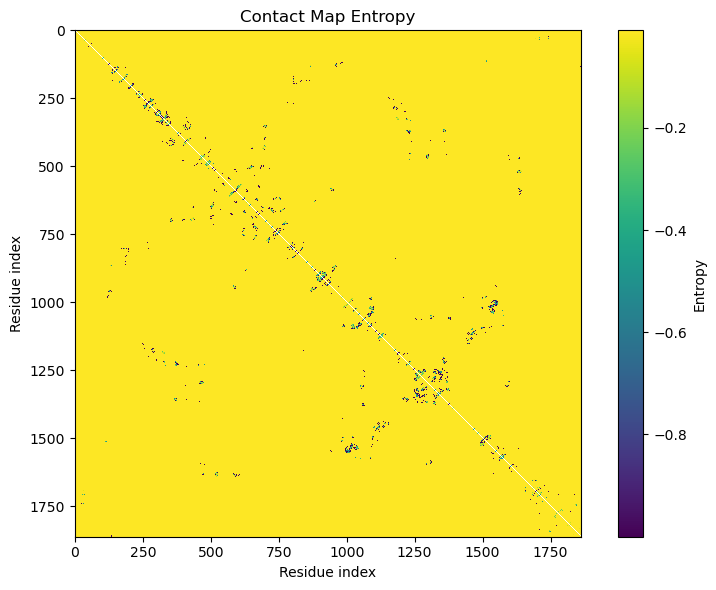

In [93]:
entropy_map = cf.plot_contact_map_entropy(contact_maps_binary)

Difference-vs-REF map shape: (1863, 1863)
Expanding x-axis by 3
Expanding y-axis by 3


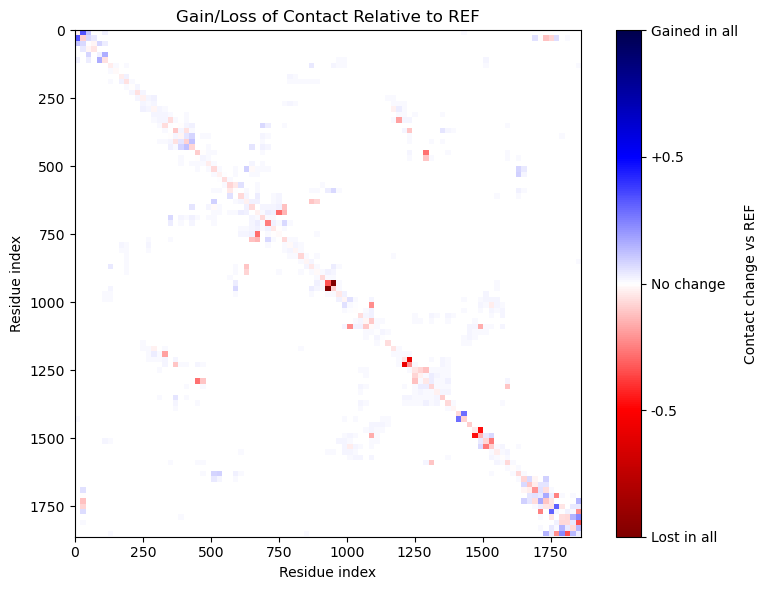

In [94]:
diff_map = cf.plot_contact_map_diff(contact_maps_binary) 

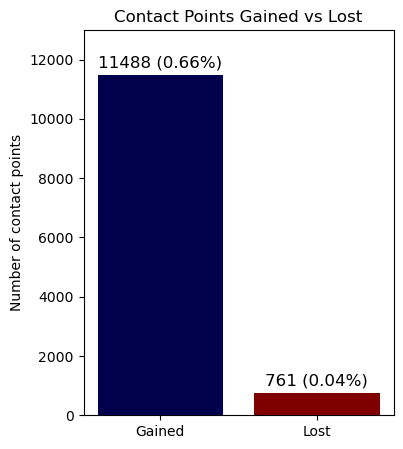

In [100]:
gained_lost_df = cf.plot_contact_map_diff_barplot(diff_map)

### Contact map variation: grid

100%|██████████| 10/10 [00:00<00:00, 41.86it/s]


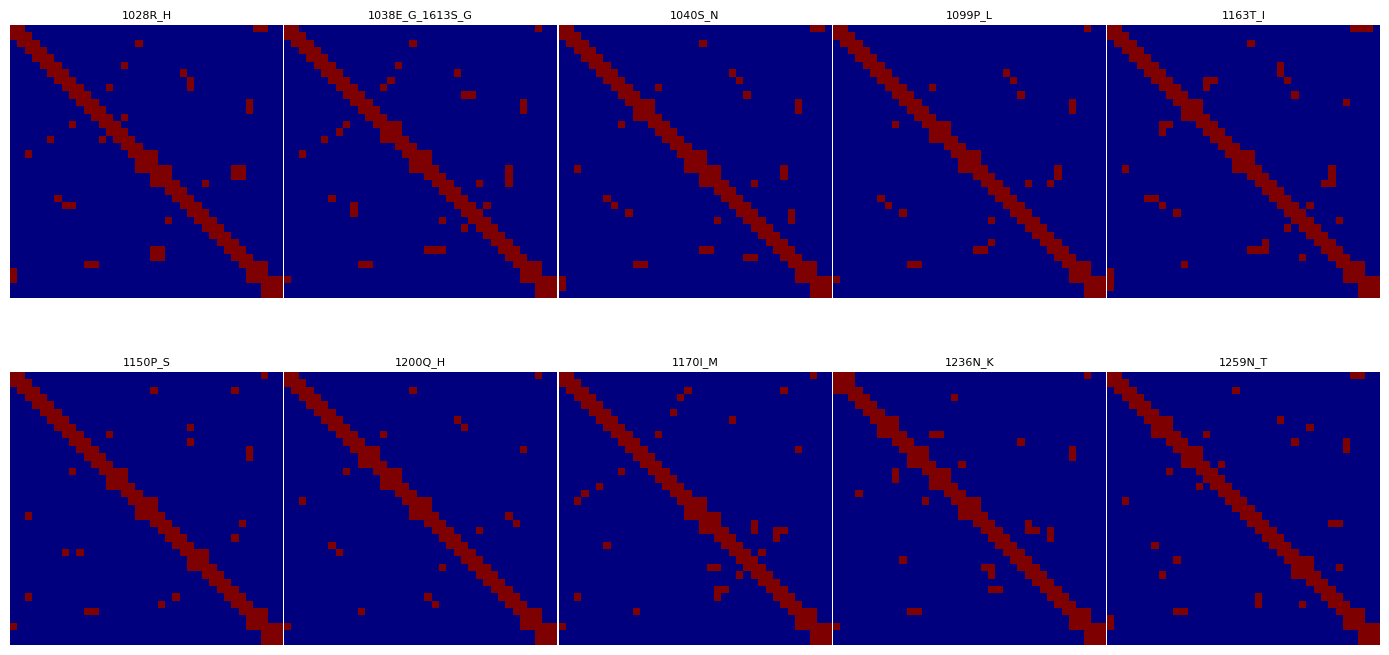

In [40]:
max_subplots = 10   
fig, axes = plt.subplots(2, 5, figsize=(14, 8))
axes = axes.flatten()

show_diag = False
for i, (name, contact_map) in enumerate(tqdm(list(contact_maps.items())[:max_subplots])):
    ### Bin the matrix   
    bin_size = 50
    log_after_bin = False
    pow = 4
    cmap = "jet" 

    if not show_diag:
        np.fill_diagonal(contact_map, np.nan)
    
    contact_map_binned = cf.bin_matrix(X=contact_map**pow, 
                                       bin_size=bin_size )
    
    # if not show_diag:
    #     np.fill_diagonal(contact_map_binned, np.nan)

    n_bins = contact_map_binned.shape[0]
     
    # Create the plot in the grid
    im = axes[i].imshow(contact_map_binned, 
                        cmap=cmap, 
                        interpolation="nearest")
    protein_id = os.path.basename(name).split("_unrelaxed")[0].split("_")[0]
    haplotype_id = os.path.basename(name).split("_unrelaxed")[0].replace(protein_id+"_","")
    axes[i].set_title(f"{haplotype_id}", fontsize=8)
    axes[i].axis('off')

plt.tight_layout(h_pad=0.0001, w_pad=0.1)
plt.show()

### Contact map variation: GIF

Create a GIF that shows each haplotype-specific contact map in random order.

In [17]:
frames = cf.animate_contact_maps_variation(contact_maps, 
                                           bin_size=2,
                                           n_frames=None)

100%|██████████| 108/108 [00:25<00:00,  4.27it/s]


### Contact map differences

Compute global distances between each pairwise combination of contact maps.

In [10]:
# # Compute differences between contact maps
# import pandas as pd
# import numpy as np

# # Get all unique sample IDs from contact map keys
# sample_ids = list(contact_maps.keys())

# def process_sample_id(sample_id):
#     return os.path.basename(sample_id).split(".")[0]

# # Create DataFrame to store differences
# differences_data = []

# # Compare each pair of contact maps
# for i, sample1 in tqdm(enumerate(sample_ids), 
#                        total=len(sample_ids), 
#                        desc="Comparing contact maps"):
#     for j, sample2 in enumerate(sample_ids):
#         if i < j:  # Only compute upper triangle to avoid duplicates
            
#             contact_map1 = contact_maps[sample1]
#             contact_map2 = contact_maps[sample2]
            
#             if contact_map1 is not None and contact_map2 is not None:
#                 # Compute difference
#                 diff = np.abs(contact_map1 - contact_map2)
#                 mean_diff = np.mean(diff)
#                 max_diff = np.max(diff)
#                 std_diff = np.std(diff)
                
#                 differences_data.append({
#                     'sample1': process_sample_id(sample1),
#                     'sample2': process_sample_id(sample2),
#                     'mean_diff': mean_diff,
#                     'max_diff': max_diff,
#                     'std_diff': std_diff,
#                     'total_diff': np.sum(diff)
#                 })

# # Create DataFrame
# contact_map_differences_df = pd.DataFrame(differences_data).sort_values(by='mean_diff', ascending=False)

# # Display the results
# print(f"Computed differences between {len(sample_ids)} samples:")
# print(f"Total comparisons: {len(contact_map_differences_df)}")
# print("\nTop 10 largest mean differences:")
# print(contact_map_differences_df.head(10))

### Contact map interpolation

Computing similarity matrix between contact maps...
Creating animation with 1590 frames...
Transitioning through 107 contact maps


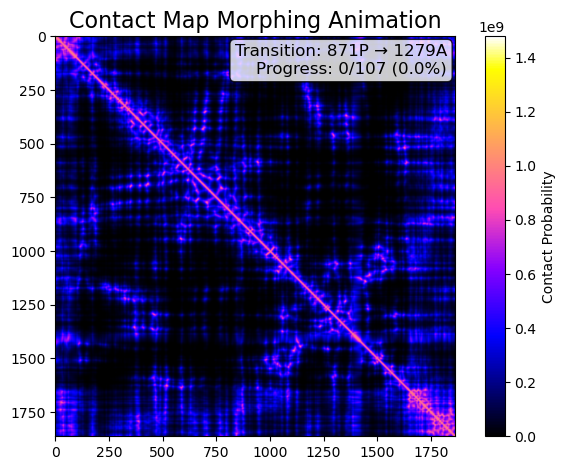

Saving animation as GIF...


KeyboardInterrupt: 

In [11]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation 
import numpy as np
from scipy.spatial.distance import pdist, squareform

pow = 4
n_frames_per_transition = 15
bin_size = 1

contact_maps_binned = {k:cf.bin_matrix(X=v**pow, bin_size=bin_size) for k,v in contact_maps.items()}

# Get all unique sample IDs from contact map keys 
sample_ids = list(contact_maps_binned.keys())

# Get the first contact map as starting point
first_sample = sample_ids[0]
first_contact_map = contact_maps_binned[first_sample]**pow

# Create a similarity matrix between all contact maps
print("Computing similarity matrix between contact maps...")
contact_map_arrays = []
valid_samples = []

for sample in sample_ids:
    cm = contact_maps_binned[sample]
    if cm is not None:
        contact_map_arrays.append(cm.flatten())
        valid_samples.append(sample)


contact_map_arrays = np.array(contact_map_arrays)

# Compute pairwise distances
distances = pdist(contact_map_arrays, metric='euclidean')
distance_matrix = squareform(distances)

# Find the optimal path through all contact maps (nearest neighbor)
def find_nearest_neighbor_path(distance_matrix, start_idx=0):
    """Find path through all points using nearest neighbor algorithm"""
    n = len(distance_matrix)
    unvisited = set(range(n))
    path = [start_idx]
    unvisited.remove(start_idx)
    
    current = start_idx
    while unvisited:
        # Find nearest unvisited neighbor
        min_dist = float('inf')
        nearest = None
        
        for neighbor in unvisited:
            dist = distance_matrix[current, neighbor]
            if dist < min_dist:
                min_dist = dist
                nearest = neighbor
        
        path.append(nearest)
        unvisited.remove(nearest)
        current = nearest
    
    return path

# Find the optimal path
random_order = True
if random_order:
    np.random.seed(42)
    optimal_path = np.random.permutation(len(sample_ids))
else:
    optimal_path = find_nearest_neighbor_path(distance_matrix)

# Create the animation
fig, ax = plt.subplots()
ax.set_title("Contact Map Morphing Animation", fontsize=16)

# Normalize all contact maps to same range for consistent visualization
all_maps = [contact_maps_binned[valid_samples[i]] for i in optimal_path]
vmin = min(np.min(cm) for cm in all_maps)
vmax = max(np.max(cm) for cm in all_maps)

# Create initial image
img = ax.imshow(first_contact_map, cmap='gnuplot2', vmin=vmin, vmax=vmax)
plt.colorbar(img, ax=ax, label='Contact Probability')

# Add text annotation
text_annotation = ax.text(0.02, 0.98, f'Sample: {os.path.basename(valid_samples[optimal_path[0]]).split(".")[0]}', 
                         transform=ax.transAxes, fontsize=12, 
                         verticalalignment='top',
                         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

def animate(frame, 
            n_frames_per_transition = n_frames_per_transition):
    """Animate function for smooth morphing between contact maps"""
    # Calculate which two maps to interpolate between
    n_maps = len(optimal_path)
    total_frames = (n_maps - 1) * n_frames_per_transition
    
    if frame >= total_frames:
        frame = total_frames - 1
    
    map_idx = frame // n_frames_per_transition
    transition_progress = (frame % n_frames_per_transition) / n_frames_per_transition
    
    # Get the two maps to interpolate between
    map1_idx = optimal_path[map_idx]
    map2_idx = optimal_path[map_idx + 1]
    
    map1 = contact_maps_binned[valid_samples[map1_idx]]
    map2 = contact_maps_binned[valid_samples[map2_idx]]

    # Linear interpolation between the two maps
    interpolated_map = (1 - transition_progress) * map1 + transition_progress * map2
    
    # Update the image
    img.set_array(interpolated_map)
    
    # Update the text annotation
    sample1_name = os.path.basename(valid_samples[map1_idx]).split("_unrelaxed")[0].split("_")[1]
    sample2_name = os.path.basename(valid_samples[map2_idx]).split("_unrelaxed")[0].split("_")[1]
    text_annotation.set_text(f'Transition: {sample1_name} → {sample2_name}\nProgress: {map_idx}/{n_maps} ({transition_progress:.1%})')
    text_annotation.set_position((0.98, 0.98))  # Position at top-right corner
    text_annotation.set_horizontalalignment('right')  # Anchor text to the right
    
    return [img, text_annotation]

# Create animation
n_maps = len(optimal_path)
total_frames = (n_maps - 1) * n_frames_per_transition

print(f"Creating animation with {total_frames} frames...")
print(f"Transitioning through {n_maps} contact maps")

anim = animation.FuncAnimation(fig, animate, frames=total_frames, 
                               interval=50, blit=True, repeat=True)

plt.tight_layout()
plt.show()

# Save the animation as GIF
print("Saving animation as GIF...")
gif_filename = 'results/plots/contact_map_interpolation.gif'
fps = 10
anim.save(gif_filename, writer='pillow', fps=fps, dpi=100)
print(f"Animation saved as '{gif_filename}'")

# Display some statistics about the path
print(f"\nAnimation Statistics:")
print(f"Number of contact maps: {n_maps}")
print(f"Total animation frames: {total_frames}")
print(f"Frames per transition: {n_frames_per_transition}")
print(f"Animation duration: {total_frames * 0.1:.1f} seconds")
print(f"GIF saved with {fps} FPS")

# Show the path taken
print(f"\nPath taken through contact maps:")
for i, idx in enumerate(optimal_path):
    sample_name = os.path.basename(valid_samples[idx]).split(".")[0]
    print(f"{i+1:2d}. {sample_name}")



## Plot high-variance regions

In [18]:
# Compute variance across all contact maps to find maximally variable regions
import numpy as np

# Stack all contact maps into a 3D array
contact_maps_array = np.stack(list(contact_maps.values()))

# Compute variance across the first dimension (across all contact maps)
variance_map = np.var(contact_maps_array, axis=0)

print(f"Variance map shape: {variance_map.shape}")
print(f"Variance range: {np.min(variance_map):.6f} to {np.max(variance_map):.6f}")
figsize=None
dpi=300

# Plot the variance map to visualize regions of high variability
plt.figure(figsize=figsize, dpi=dpi)
plt.imshow(variance_map, cmap='PuRd', interpolation='nearest')
plt.colorbar(label='Variance')
plt.title(f'Contact Map Variance Across All Structures (n={contact_maps_array.shape[0]})')
plt.xlabel('Residue Position')
plt.ylabel('Residue Position')
plt.show()

# Find the regions with highest variance
# Get the top 10% of variance values
variance_threshold = np.percentile(variance_map, 90)
high_variance_mask = variance_map > variance_threshold

print(f"Top 10% variance threshold: {variance_threshold:.6f}")
print(f"Number of high-variance positions: {np.sum(high_variance_mask)}")

# Plot high variance regions
plt.figure(figsize=figsize, dpi=dpi)
plt.imshow(high_variance_mask, cmap='PuRd', interpolation='nearest')
plt.colorbar(label='High Variance (Top 10%)')
plt.title(f'Regions of Maximum Variability Across Contact Maps (n={contact_maps_array.shape[0]})')
plt.xlabel('Residue Position')
plt.ylabel('Residue Position')
plt.show()


# Optional: Get coordinates of highest variance positions
high_variance_coords = np.where(high_variance_mask)
print(f"Coordinates of highest variance regions:")
for i in range(min(10, len(high_variance_coords[0]))):
    row, col = high_variance_coords[0][i], high_variance_coords[1][i]
    variance_value = variance_map[row, col]
    print(f"  Position ({row}, {col}): variance = {variance_value:.6f}")


ValueError: all input arrays must have the same shape

### Get Predicted Aligned Error (PAE)

📘 What is PAE?
- predicted_aligned_error[i, j] = expected positional error in Ångströms at residue i when the predicted and true structures are aligned on residue j

- Asymmetric matrix: PAE[i,j] ≠ PAE[j,i]

- Useful for identifying flexible domains or low-confidence interdomain contacts

In [9]:
# Read PAE from JSON file
import json

base_dir = os.path.expanduser("~/projects/data/colabfold")
pae_files = glob.glob(os.path.join(base_dir,
                                   "ENST00000357654",
                                   "**", 
                                "af2_sameMSA/*_predicted_aligned_error_v1.json"
                                   ),
                       recursive=True)

# Load PAE data from JSON file
pae_matrices = {}
for pae_file in tqdm(pae_files, desc="Loading PAE matrices"):
    with open(pae_file, 'r') as f:
        pae_data = json.load(f)

    # Extract PAE matrix from the JSON structure
    # The exact structure depends on the JSON format, but typically it contains a 2D array
    if 'predicted_aligned_error' in pae_data:
        pae_matrices[pae_file] = np.array(pae_data['predicted_aligned_error']) 
    

Loading PAE matrices: 100%|██████████| 53/53 [00:24<00:00,  2.13it/s]


In [10]:
# Calculate mean PAE across all structures
pae_matrix = np.mean(np.array(list(pae_matrices.values())), axis=0)
     
print(f"PAE matrix shape: {pae_matrix.shape}")
print(f"PAE range: {np.min(pae_matrix):.3f} - {np.max(pae_matrix):.3f}")
print(f"Mean PAE: {np.mean(pae_matrix):.3f}")

PAE matrix shape: (1863, 1863)
PAE range: 0.250 - 30.660
Mean PAE: 26.398


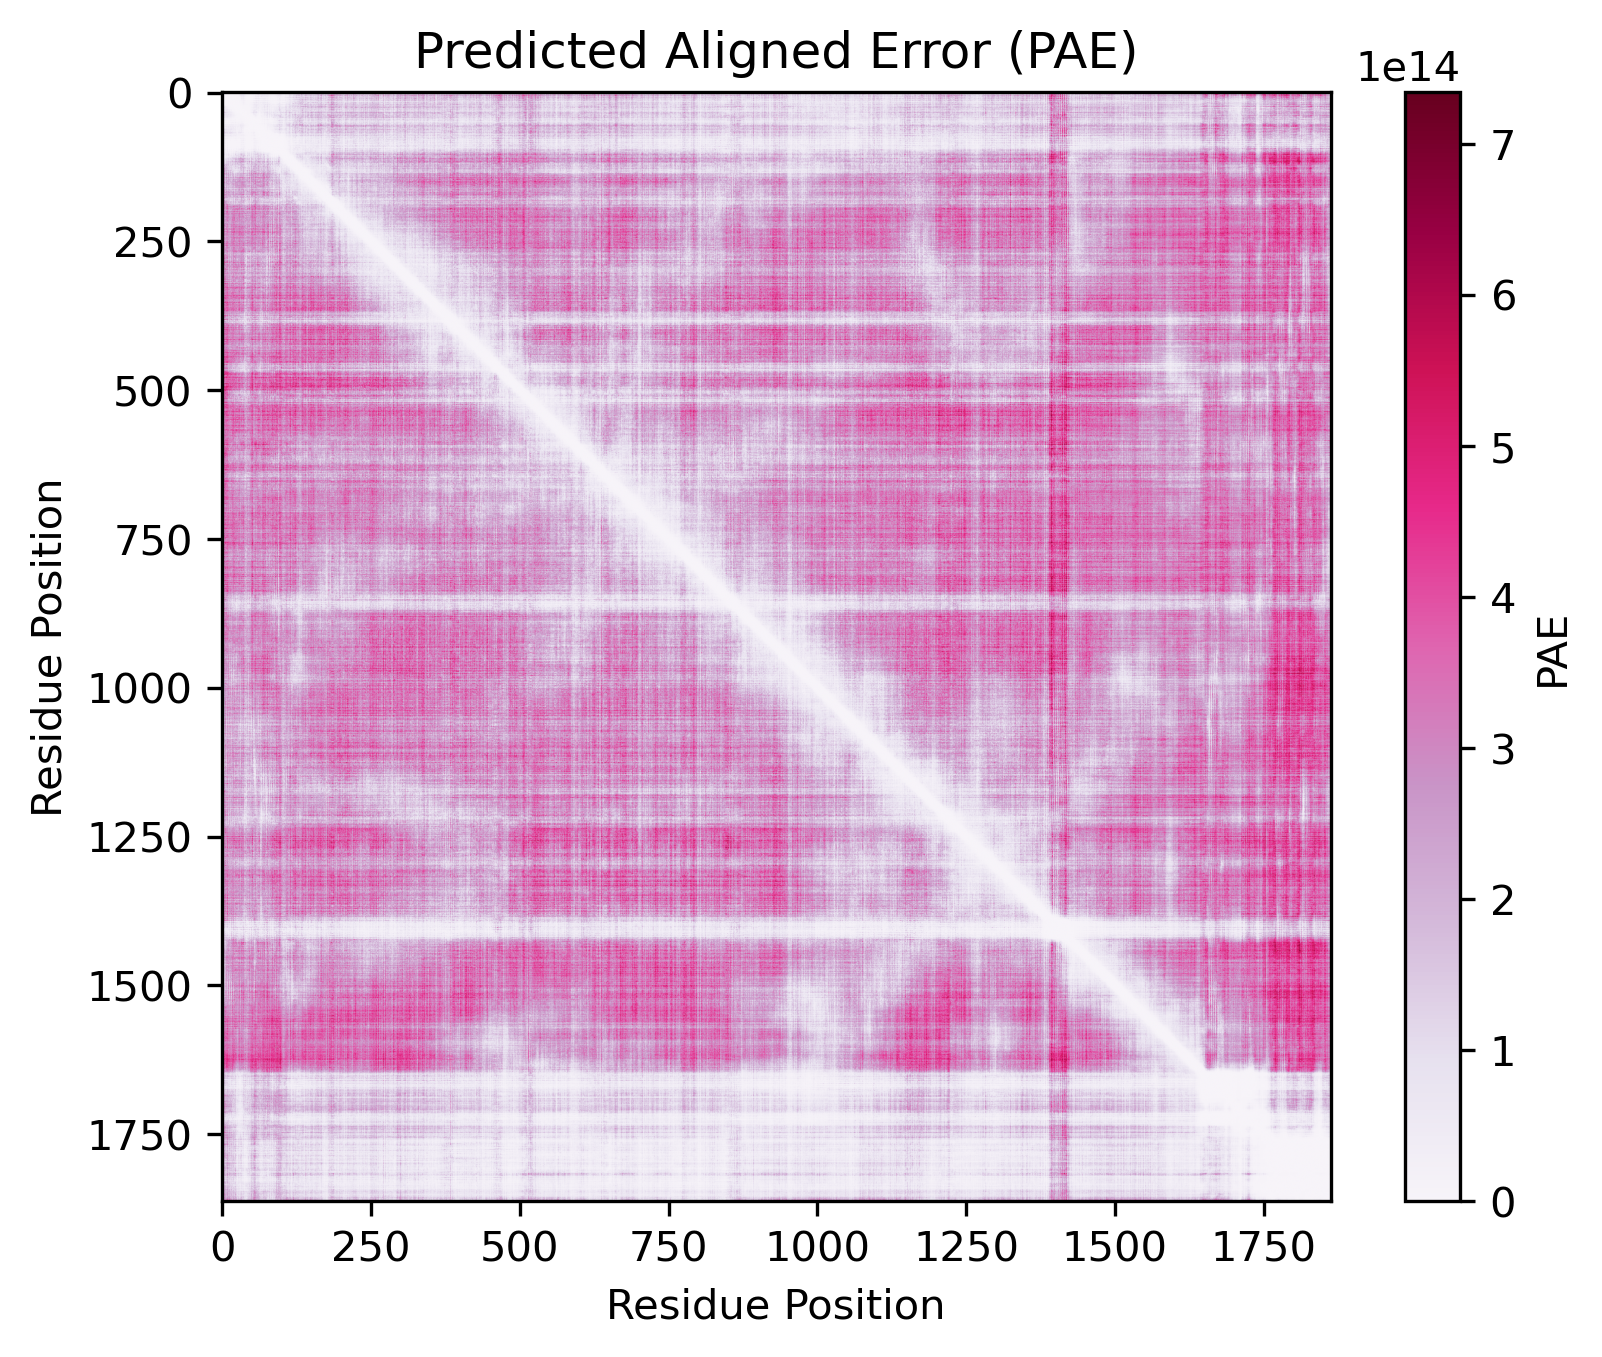

In [11]:
plt.figure(dpi=300)
plt.imshow(pae_matrix**10, cmap="PuRd")
plt.colorbar(label="PAE")
plt.title("Predicted Aligned Error (PAE)")
plt.xlabel("Residue Position")
plt.ylabel("Residue Position")
plt.show()

### Does Predicted Aligned Error correlate with contact map variance?

Pearson correlation: 0.1917 (p-value: 0.0000e+00)
Spearman correlation: 0.1754 (p-value: 0.0000e+00)


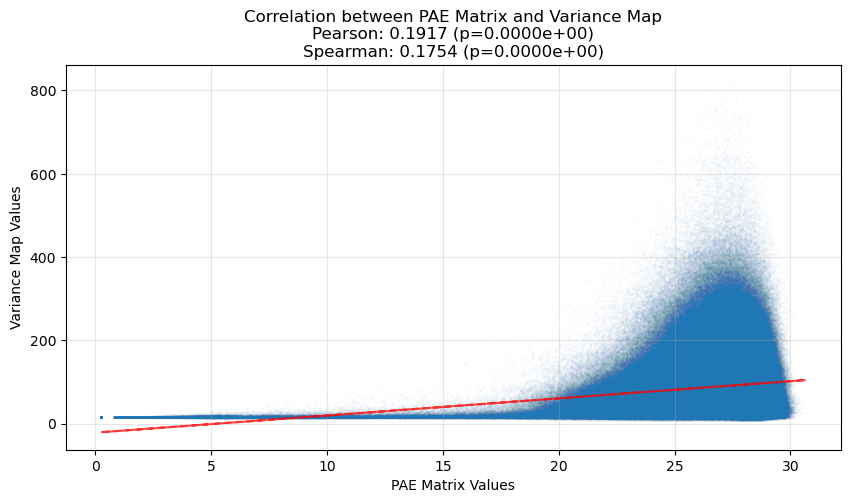


Interpretation: There is a weak positive correlation between PAE matrix and variance map values.


In [12]:
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np


# Test correlation between pae_matrix and variance_map
if pae_matrix is not None and 'variance_map' in locals():
    # Flatten both matrices for correlation analysis
    pae_flat = pae_matrix.flatten()
    variance_flat = variance_map.flatten()
    
    # Calculate Pearson correlation
    pearson_corr, pearson_p = scipy.stats.pearsonr(pae_flat, variance_flat)
    
    # Calculate Spearman correlation (rank-based)
    spearman_corr, spearman_p = scipy.stats.spearmanr(pae_flat, variance_flat)
    
    print(f"Pearson correlation: {pearson_corr:.4f} (p-value: {pearson_p:.4e})")
    print(f"Spearman correlation: {spearman_corr:.4f} (p-value: {spearman_p:.4e})")
    
    # Create scatter plot
    plt.figure(figsize=(10, 5))
    plt.scatter(pae_flat, variance_flat, alpha=0.01, s=1)
    # plt.hist2d(pae_flat, variance_flat, bins=100, cmap='viridis', density=True)
    plt.xlabel('PAE Matrix Values')
    plt.ylabel('Variance Map Values')
    plt.title(f'Correlation between PAE Matrix and Variance Map\nPearson: {pearson_corr:.4f} (p={pearson_p:.4e})\nSpearman: {spearman_corr:.4f} (p={spearman_p:.4e})')
    
    # Add trend line
    z = np.polyfit(pae_flat, variance_flat, 1)
    p = np.poly1d(z)
    plt.plot(pae_flat, p(pae_flat), "r--", alpha=0.8)
    
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Print interpretation
    if abs(pearson_corr) > 0.7:
        strength = "strong"
    elif abs(pearson_corr) > 0.3:
        strength = "moderate"
    else:
        strength = "weak"
    
    direction = "positive" if pearson_corr > 0 else "negative"
    print(f"\nInterpretation: There is a {strength} {direction} correlation between PAE matrix and variance map values.")
    
else:
    print("Cannot test correlation: pae_matrix or variance_map not available")


## AlphaFold embeddings

In [13]:
base_dir = os.path.expanduser("~/projects/data/colabfold")
npy_files = glob.glob(os.path.join(base_dir,
                                   "ENST00000357654",
                                   "**",
                                #  "af2_sameMSA/*_single_repr_*_model_1_*.npy"
                                 "af2_sameMSA/*_single_repr_rank*.npy"
                                # "af2_sameMSA/*_pair_repr_*_model_*.npy"
                                   ),
                       recursive=True)
print(len(npy_files),"files found") 
npy_files

265 files found


['/home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA/ENSP00000350283_1028R_H_single_repr_rank_002_alphafold2_ptm_model_2_seed_000.npy',
 '/home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA/ENSP00000350283_1028R_H_single_repr_rank_004_alphafold2_ptm_model_3_seed_000.npy',
 '/home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA/ENSP00000350283_1028R_H_single_repr_rank_001_alphafold2_ptm_model_1_seed_000.npy',
 '/home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA/ENSP00000350283_1028R_H_single_repr_rank_003_alphafold2_ptm_model_5_seed_000.npy',
 '/home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA/ENSP00000350283_1028R_H_single_repr_rank_005_alphafold2_ptm_model_4_seed_000.npy',
 '/home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA/ENSP00000350283_1038E_G_1613S_G_single_repr_rank_005_alphafold2_ptm_model_4_seed_000.npy',
 '/home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA/ENSP0000035

In [14]:
import re

af2_meta = pd.DataFrame({'protein_id': [os.path.basename(x).split("_")[0] for x in npy_files],
 'sample_id': [os.path.basename(x).split("_single")[0].split("_", 1)[1] for x in npy_files],
 'model_id': [re.search(r'model_(\d+)', os.path.basename(x)).group(1) for x in npy_files],
 'model_rank': [re.search(r'rank_(\d+)', os.path.basename(x)).group(1) for x in npy_files],
 'model_seed': [re.search(r'seed_(\d+)', os.path.basename(x)).group(1) for x in npy_files],
 'file':npy_files}
 )

af2_meta.loc[:,"edit_distance"] = (af2_meta["sample_id"].str.count("_")+1)/2
af2_meta.loc[af2_meta["sample_id"]=="REF","edit_distance"] = 0
af2_meta.head()

,protein_id,sample_id,model_id,model_rank,model_seed,file,edit_distance
0,ENSP00000350283,1028R_H,2,002,000,/home/schilder/projects/data/colabfold/ENST000...,1.0
1,ENSP00000350283,1028R_H,3,004,000,/home/schilder/projects/data/colabfold/ENST000...,1.0
2,ENSP00000350283,1028R_H,1,001,000,/home/schilder/projects/data/colabfold/ENST000...,1.0
3,ENSP00000350283,1028R_H,5,003,000,/home/schilder/projects/data/colabfold/ENST000...,1.0
4,ENSP00000350283,1028R_H,4,005,000,/home/schilder/projects/data/colabfold/ENST000...,1.0


In [15]:
# Load all embeddings
embeddings = []
for npy_file in tqdm(npy_files, desc="Loading embeddings"):
    embedding = np.load(npy_file)
    # embedding = embedding.mean(axis=1).mean(axis=1)
    embeddings.append(embedding)

# Convert to numpy array
print("Converting to numpy array")
embeddings_array = np.array(embeddings)
print(f"Loaded {len(embeddings)} embeddings with shape: {embeddings_array.shape}")

# # Option to either flatten embeddings or take mean across sequence dimension
use_mean_embedding = True  # Set to False to flatten instead

if use_mean_embedding:
    # Take mean across sequence dimension (axis=1)
    # Each embedding is (seq_length, 128), we take mean to get (128,)
    embeddings_processed = np.mean(embeddings_array, axis=1)
    print(f"Mean embeddings shape: {embeddings_processed.shape}")
else:
    # Reshape embeddings for UMAP (flatten each embedding)
    # Each embedding is (seq_length, 256), we flatten to (seq_length * 256)
    embeddings_processed = embeddings_array.reshape(embeddings_array.shape[0], -1)
    print(f"Flattened embeddings shape: {embeddings_processed.shape}")



Loading embeddings:   0%|          | 0/265 [00:00<?, ?it/s]

Loading embeddings: 100%|██████████| 265/265 [00:00<00:00, 3323.61it/s]


Converting to numpy array
Loaded 265 embeddings with shape: (265, 1863, 256)
Mean embeddings shape: (265, 256)


In [16]:
from sklearn.preprocessing import StandardScaler
# Standardize the data
scale = False
if scale:
    print("Standardizing data")
    scaler = StandardScaler()
    embeddings_scaled = scaler.fit_transform(embeddings_processed)
    print(f"Scaled embeddings shape: {embeddings_scaled.shape}")
else:
    embeddings_scaled = embeddings_processed

In [17]:
# Subset embeddings_scaled by indices where model_id == 1
model_1_indices = af2_meta[af2_meta['model_id'] == "1"].index 

In [18]:
import umap
import matplotlib.pyplot as plt

# Apply UMAP
print("Running UMAP") 

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embeddings_2d = reducer.fit_transform(embeddings_scaled[model_1_indices])


Running UMAP


/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:

af2_meta.loc[model_1_indices, "umap_1"] = embeddings_2d[:, 0]
af2_meta.loc[model_1_indices, "umap_2"] = embeddings_2d[:, 1]

def plot_umap(af2_meta, 
              color_col="edit_distance", 
              palette="plasma",
              alpha=0.8,
              interactive=False, **kwargs):
    if interactive:
        import plotly.express as px
        import plotly.graph_objects as go

        # Create the base scatter plot
        fig = px.scatter(af2_meta.sort_values(by=["sample_id","model_id", "model_rank"]), 
                        x="umap_1", y="umap_2", 
                        color=color_col, 
                        hover_data=["protein_id", "sample_id", "model_rank", "model_seed"],
                        title="UMAP Visualization of AlphaFold Single Representations",
                        **kwargs)

        # Add red diamond markers for REF samples
        ref_data = af2_meta[af2_meta["sample_id"] == "REF"]
        fig.add_trace(go.Scatter(
            x=ref_data["umap_1"],
            y=ref_data["umap_2"],
            mode='markers',
            marker=dict(
                symbol='diamond',
                size=10,
                color='rgba(255,0,0,0)',  # Transparent red (no fill)
                line=dict(width=2, color='black')
            ),
            name='REF<br>samples',
            showlegend=True,
            hoverinfo='skip'
        ))

        # Make the colorbar shorter and anchor to bottom
        fig.update_layout(
            coloraxis_colorbar=dict(
                len=0.6,  # Reduce colorbar length to 60% of default
                yanchor="bottom",
                y=0.0,
                title=dict(text="edit_distance".replace("_", "<br>"))
            )
        )

        fig.show()
    else:
        import matplotlib.pyplot as plt
        import seaborn as sns
        # Create visualization
        print("Creating visualization")
        plt.figure(figsize=(12, 8))
        sns.scatterplot(data=af2_meta.sort_values(by=["sample_id","model_id", "model_rank"]), 
                        x="umap_1", y="umap_2", 
                        hue=color_col, 
                        palette=palette,
                        alpha=alpha, 
                        s=50,
                        **kwargs)
        plt.title('UMAP Visualization of AlphaFold Single Representations')
        plt.xlabel('UMAP 1')
        plt.ylabel('UMAP 2')
        plt.grid(True, alpha=0.3)
        plt.show() 

plot_umap(af2_meta, interactive=True, color_col="edit_distance")

## Inteactive UMAP with contact maps

In [ ]:
from src.colabfold import create_interactive_umap_with_contact_maps
from bokeh.plotting import show
from bokeh.io import output_notebook

# Enable Bokeh in Jupyter
output_notebook()

# Create interactive plot
layout = create_interactive_umap_with_contact_maps(
    af2_meta=af2_meta,
    contact_maps=contact_maps,
    use_bokeh=True,  # Use Bokeh instead of Plotly
    color_col='sample_id',
    hover_cols=['sample_id', 'edit_distance']
)

# Display in notebook
show(layout)

Loading BokehJS ...

 '1613S_G' '356Q_R_1512S_I' '1710G_R' '186S_Y_871P_L_1183K_R_1613S_G'
 '1801G_D' '179Y_C_486F_L_550N_H' '1783M_T' '1804V_D'
 '245D_Y_723N_D_871P_L_1183K_R_1613S_G'
 '332R_Q_871P_L_1038E_G_1183K_R_1613S_G' '356Q_R'
 '271V_M_871P_L_1038E_G_1183K_R_1613S_G' '228F_Y_871P_L'
 '191V_I_871P_L_1038E_G_1183K_R_1613S_G'
 '209P_L_871P_L_1038E_G_1183K_R_1613S_G' '246L_V'
 '275G_S_871P_L_1038E_G_1183K_R_1613S_G' '308S_T_871P_L_1140S_G'
 '356Q_R_1275I_V' '36S_Y_871P_L_1038E_G_1183K_R_1613S_G_1652M_I'
 '476H_R_820K_E_871P_L_1183K_R_1613S_G' '379I_M_871P_L'
 '411D_E_871P_L_1038E_G_1183K_R_1613S_G'
 '391E_Q_871P_L_1038E_G_1183K_R_1613S_G' '466R_Q'
 '596L_F_871P_L_1038E_G_1183K_R_1613S_G'
 '539T_M_871P_L_1038E_G_1183K_R_1613S_G'
 '504R_C_871P_L_1038E_G_1183K_R_1613S_G' '487V_F_871P_L'
 '504R_H_871P_L_1038E_G_1183K_R_1613S_G' '571I_M_871P_L'
 '571I_T_871P_L_1038E_G_1183K_R_1613S_G' '607K_E' '59S_L_356Q_R'] will be assigned to `nan_color` gray


Bokeh interactive plot created for Jupyter notebook.
Use show(layout) to display it in the notebook.


In [ ]:

from src.colabfold import create_dash_interactive_umap_app

# Create Dash app
app = create_dash_interactive_umap_app(
    af2_meta=af2_meta,
    contact_maps=contact_maps,
    color_col='population',
    size_col='confidence',
    hover_cols=['sample_id', 'edit_distance']
)

# Run the app
app.run(debug=True, port=8050)
# Open browser to http://localhost:8050